# Colab Setup

**For Colab users:** Uncomment and run the cell below to mount Drive.  
**For local users:** Skip this cell.

In [20]:
# Uncomment for Colab:
#from google.colab import drive
#drive.mount('/content/drive')

## Setup: Dependency Verification and Installation

This cell checks for the presence of essential Python libraries (like `numpy`, `torch`, `musdb`, `nbformat`, etc.).
If any required library is not found, it attempts to install it automatically using `pip`.
It also verifies the availability of PyTorch with CUDA, which is crucial for GPU-accelerated training.

In [21]:
# --- 1. Verify and install dependencies ---
print("Verifying and installing missing packages if necessary...")

packages_to_check = [
    'numpy', 'matplotlib', 'librosa', 'tqdm', 'sklearn', 'stempeg', 'torch', 'torchvision', 'torchaudio', 'musdb'
]

for package in packages_to_check:
    try:
        __import__(package)
        print(f"  ✅ {package} is installed.")
    except ImportError:
        print(f"  ❌ {package} is NOT installed. Attempting to install...")
        try:
            import sys
            import subprocess
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
            __import__(package)
            print(f"  ✅ {package} is now installed.")
        except Exception as e:
            print(f"  ❌ Failed to install {package}: {e}")

# Special check for PyTorch CUDA
print("\n--- PyTorch CUDA status ---")
try:
    import torch
    if torch.cuda.is_available():
        print(f"  ✅ PyTorch with CUDA (version {torch.version.cuda}) is available.")
        print(f"     CUDA Device Name: {torch.cuda.get_device_name(0)}")
    else:
        print("  ⚠️ PyTorch is installed, but CUDA is NOT available.")
except ImportError:
    print("  ❌ PyTorch is not installed.")

print("Verification complete.")

Verifying and installing missing packages if necessary...
  ✅ numpy is installed.
  ✅ matplotlib is installed.
  ✅ librosa is installed.
  ✅ tqdm is installed.
  ✅ sklearn is installed.
  ✅ stempeg is installed.
  ✅ torch is installed.
  ✅ torchvision is installed.
  ✅ torchaudio is installed.
  ✅ musdb is installed.

--- PyTorch CUDA status ---
  ⚠️ PyTorch is installed, but CUDA is NOT available.
Verification complete.


## Imports and Environment Setup

- Import required libraries (torch, numpy, matplotlib, etc.)

- Set device (CPU/GPU)

In [22]:
import sys
from pathlib import Path
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from IPython.display import Audio, display
import importlib

# Detect environment and set Project Root
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning')
    print(f"✅ Colab Project Root: {PROJECT_ROOT}")
else:
    # Local: use current working directory
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'modelA.ipynb').exists():
        for p in [PROJECT_ROOT] + list(PROJECT_ROOT.parents):
            if (p / 'modelA.ipynb').exists():
                PROJECT_ROOT = p
                break

os.chdir(PROJECT_ROOT)

# Define data and checkpoint directories
DATA_DIR = PROJECT_ROOT / "data"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Add to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import project modules
import models.utils as utils
importlib.reload(utils)
from models import model_A as ma
importlib.reload(ma)

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

# Device setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"\nConfiguration Complete:")
print(f"   - Device: {device}")
print(f"   - Working Directory: {os.getcwd()}")
print(f"   - Data Directory: {DATA_DIR}")
print(f"   - Checkpoints Directory: {CHECKPOINT_DIR}")


Configuration Complete:
   - Device: cpu
   - Working Directory: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning
   - Data Directory: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\data
   - Checkpoints Directory: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\checkpoints


## MUSDB18 Setup

**Quick Start:**
1. Download MUSDB18
2. Extract to project folder as `musdb18/`
3. Run preprocessing below

**Expected structure:**
```
musdb18/
  train/     (~100 songs)
  valid/     (~14 songs)
  test/      (~50 songs)
```

In [23]:
# ============================================================================
# MUSDB18 PATH CONFIGURATION
# ============================================================================
# Auto-detect musdb18 folder in project directory
MUSDB18_PATH = PROJECT_ROOT / "musdb18"

if not MUSDB18_PATH.exists():
    print("⚠️  MUSDB18 folder not found!")
    print(f"   Expected location: {MUSDB18_PATH}")
    print("")
    print("📥 Download MUSDB18:")
    print("   1. Register at https://zenodo.org/record/1438122")
    print("   2. Download MUSDB18-HQ.zip (~22GB)")
    print("   3. Extract to project folder as 'musdb18'")
    print("")
    MUSDB18_PATH = None
else:
    # Check for required subfolders
    train_dir = MUSDB18_PATH / "train"
    valid_dir = MUSDB18_PATH / "valid"
    test_dir = MUSDB18_PATH / "test"

    if train_dir.exists() and test_dir.exists():
        num_train = len(list(train_dir.iterdir()))
        num_valid = len(list(valid_dir.iterdir())) if valid_dir.exists() else 0
        num_test = len(list(test_dir.iterdir()))
        print(f"✅ MUSDB18 dataset found: {MUSDB18_PATH}")
        print(f"   Train: {num_train} tracks")
        print(f"   Valid: {num_valid} tracks")
        print(f"   Test: {num_test} tracks")
    else:
        print(f"⚠️  Found musdb18 folder but missing train/test subfolders")
        print(f"   Path: {MUSDB18_PATH}")
        MUSDB18_PATH = None

# Initialize file lists (will be populated after preprocessing)
mix_files_stage1 = mix_files_stage2 = tgt_files_stage1 = tgt_files_stage2 = []

✅ MUSDB18 dataset found: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\musdb18
   Train: 100 tracks
   Valid: 16 tracks
   Test: 50 tracks


## Data Preprocessing

Preprocess MUSDB18 into 8-second waveform chunks for training, validation, and testing.

In [24]:
# ============================================================================
# DATA PREPROCESSING & PATH SETUP
# ============================================================================
import os
import shutil
import time
import zipfile
from pathlib import Path
from tqdm import tqdm

# ============================================================================
# 1. SETUP PATHS
# ============================================================================
# Define where your zip is on Drive (Update this path if needed!)
drive_zip_path = PROJECT_ROOT / "data.zip"

# Define where we want the data to live (Fast Local Disk)
local_extract_root = Path("/content/local_data")
local_data_dir = local_extract_root / "data"

# ============================================================================
# 2. DISK SPACE CHECK & EXTRACTION
# ============================================================================
if IN_COLAB:
    print(f"🔍 Checking for local data at: {local_data_dir}")

    # Check if data already exists to avoid re-unzipping
    if not local_data_dir.exists():
        print("🚀 Data not found locally. Starting extraction...")
        print(f"📂 Source: {drive_zip_path}")
        print(f"📂 Destination: {local_extract_root}")

        # Create destination folder
        local_extract_root.mkdir(parents=True, exist_ok=True)

        if drive_zip_path.exists():
            t0 = time.time()
            print("⏳ Unzipping from Drive with progress tracking...")

            try:
                with zipfile.ZipFile(drive_zip_path, 'r') as zip_ref:
                    # Get list of files
                    file_list = zip_ref.namelist()

                    # Extract with progress bar
                    for file in tqdm(file_list, desc="📦 Extracting", unit="file"):
                        zip_ref.extract(file, local_extract_root)

                t_final = time.time() - t0
                print(f"✅ Unzip complete in {t_final/60:.1f} minutes!")
                DATA_DIR = local_data_dir
            except Exception as e:
                print(f"❌ Unzip failed: {e}")
                print("   Falling back to Drive path (slow)")
                DATA_DIR = PROJECT_ROOT / "data"
        else:
            print(f"❌ Error: Could not find {drive_zip_path}")
            print("   Please ensure 'data.zip' is uploaded to your Drive project folder.")
            DATA_DIR = PROJECT_ROOT / "data" # Fallback (slow)

    else:
        print("✅ Fast local data already exists! Skipping unzip.")
        DATA_DIR = local_data_dir

    print(f"📍 DATA_DIR set to: {DATA_DIR}")

    # Check remaining disk space
    total, used, free = shutil.disk_usage("/")
    print(f"💾 Disk Space: {free // (2**30)} GB free / {total // (2**30)} GB total")

else:
    # Local PC
    DATA_DIR = PROJECT_ROOT / "data"
    print(f"💻 Running locally. Using repo data: {DATA_DIR}")

# ============================================================================
# 3. CONFIGURE UTILS
# ============================================================================
SAMPLE_RATE = 22050
CHUNK_DURATION = 8.0
CHUNK_OVERLAP = 4.0

if MUSDB18_PATH:
    utils.MUSDB_SPLITS = {
        'train': MUSDB18_PATH / 'train',
        'val': MUSDB18_PATH / 'valid',
        'test': MUSDB18_PATH / 'test',
    }
    utils.DATA_DIR = DATA_DIR
    utils.SAMPLE_RATE = SAMPLE_RATE
    utils.CHUNK_DURATION = CHUNK_DURATION
    utils.CHUNK_OVERLAP = CHUNK_OVERLAP

    # Since files are unzipped, these functions will see them and skip generation
    utils.process_stage1()
    utils.process_stage2()

    print(f"\n{'='*70}")
    print("🎯 SYSTEM READY")
    print(f"{'='*70}")
else:
    print("⚠️  MUSDB18_PATH not set - skipping preprocessing")

💻 Running locally. Using repo data: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\data

STAGE 1: vocals+other → other (single stem)
⏭️  train: already exists, skipping...
⏭️  val: already exists, skipping...
⏭️  test: already exists, skipping...

STAGE 2: all 4 stems → accompaniment (3 stems)
⏭️  train: already exists, skipping...
⏭️  val: already exists, skipping...
⏭️  test: already exists, skipping...

🎯 SYSTEM READY


## Model A: Two Architectures for Comparison

**Model A (LSTM)** 1️⃣: Sequential bidirectional LSTM with masking output.

**Model A (U-Net)** 2️⃣: 2D CNN encoder-decoder with skip connections.

In [25]:
print("="*70)
print("MODEL A ARCHITECTURES")
print("="*70)

# Quick architecture preview
lstm_preview, _, _, _ = utils.initialize_model_a_lstm(device)
unet_preview, _, _, _ = utils.initialize_model_a_unet(device)

lstm_params = sum(p.numel() for p in lstm_preview.parameters())
unet_params = sum(p.numel() for p in unet_preview.parameters())

print("\n1️⃣ Model A (LSTM):")
print(f"   Parameters: {lstm_params:,}")
print(f"   Type: Bidirectional LSTM with masking")

print("\n2️⃣ Model A (U-Net):")
print(f"   Parameters: {unet_params:,}")
print(f"   Type: 2D CNN encoder-decoder")

# Clean up preview models
del lstm_preview, unet_preview
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "="*70)

MODEL A ARCHITECTURES

1️⃣ Model A (LSTM):
   Parameters: 13,656,067
   Type: Bidirectional LSTM with masking

2️⃣ Model A (U-Net):
   Parameters: 21,665,697
   Type: 2D CNN encoder-decoder



## Train Both Models - Stage 1

Sequential training: LSTM first, then U-Net

In [26]:
# ============================================================================
# TRAIN BOTH MODEL A ARCHITECTURES - STAGE 1 (2 -> 1)
# ============================================================================
import torch.optim as optim
import torch.nn as nn
from models import model_A as ma

SKIP_TRAINING_STAGE1 = False
CHUNK_DURATION = 8.0

print(f"\n{'='*70}")
print('STAGE 1 TRAINING: 2 → 1')
print(f"{'='*70}\n")

# Checkpoints
ckpt_lstm_s1 = CHECKPOINT_DIR / f'model_a_lstm_stage1_{CHUNK_DURATION:.0f}s.pth'
ckpt_unet_s1 = CHECKPOINT_DIR / f'model_a_unet_stage1_{CHUNK_DURATION:.0f}s.pth'

# Auto-skip
skip_lstm_s1 = SKIP_TRAINING_STAGE1 or ckpt_lstm_s1.exists()
skip_unet_s1 = SKIP_TRAINING_STAGE1 or ckpt_unet_s1.exists()

# --- 1. Train LSTM (FAST CONFIG) ---
print('1️⃣ Model A (LSTM) - Stage 1')
print('-' * 70)
if ckpt_lstm_s1.exists():
    print(f"⏭️  LSTM Stage 1 checkpoint found: {ckpt_lstm_s1.name}")

fast_lstm_config = utils.get_training_config_lstm()
fast_lstm_config['batch_size'] = 128 # LSTM is fine with big batches

model_lstm, processor_lstm, optimizer_lstm, loss_fn_lstm = utils.initialize_model_a_lstm(device)
hist_lstm_s1 = utils.train_model_stage(
    model=model_lstm,
    processor=processor_lstm,
    optimizer=optimizer_lstm,
    loss_fn=loss_fn_lstm,
    training_data_dir=DATA_DIR,
    stage='stage1',
    ckpt_path=ckpt_lstm_s1,
    device=device,
    train_config=fast_lstm_config,
    skip_training=skip_lstm_s1
)

# Free Memory
import gc
model_lstm = model_lstm.to('cpu')
del optimizer_lstm
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

# --- 2. Train U-Net (CORRECTED A100 CONFIG) ---
print('\n2️⃣ Model A (U-Net) - Stage 1')
print('-' * 70)
if ckpt_unet_s1.exists():
    print(f"⏭️  U-Net Stage 1 checkpoint found: {ckpt_unet_s1.name}")

# CONFIG: Use Batch Size 32 (Safe limit for massive spectrograms)
fast_unet_config = utils.get_training_config_unet()
fast_unet_config['batch_size'] = 32  # <--- CHANGED FROM 128 to 32

# MANUAL INITIALIZATION (Light Model)
print("📉 Initializing Optimized U-Net (32 filters, 5 layers)...")
model_unet = ma.TimeFrequencyDomainUNet(
    in_channels=1,
    out_channels=1,
    base_filters=32,
    num_layers=5,
    batchnorm=True,
    dropout=0.1
).to(device)

# Manual Optimizer Setup
processor_unet = utils.AudioProcessor(device=device)
optimizer_unet = optim.Adam(model_unet.parameters(), lr=fast_unet_config['learning_rate'])
loss_fn_unet = nn.MSELoss()

# Train
hist_unet_s1 = utils.train_model_stage(
    model=model_unet,
    processor=processor_unet,
    optimizer=optimizer_unet,
    loss_fn=loss_fn_unet,
    training_data_dir=DATA_DIR,
    stage='stage1',
    ckpt_path=ckpt_unet_s1,
    device=device,
    train_config=fast_unet_config,
    skip_training=skip_unet_s1
)

print(f"\n{'='*70}")
print('✅ STAGE 1 COMPLETE!')
print(f"{'='*70}")


STAGE 1 TRAINING: 2 → 1

1️⃣ Model A (LSTM) - Stage 1
----------------------------------------------------------------------
⏭️  LSTM Stage 1 checkpoint found: model_a_lstm_stage1_8s.pth
✅ Found checkpoint: model_a_lstm_stage1_8s.pth
   Best val loss: 0.009270

2️⃣ Model A (U-Net) - Stage 1

c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\models\utils.py:1495: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  check


----------------------------------------------------------------------
⏭️  U-Net Stage 1 checkpoint found: model_a_unet_stage1_8s.pth
📉 Initializing Optimized U-Net (32 filters, 5 layers)...
✅ Found checkpoint: model_a_unet_stage1_8s.pth
   Best val loss: 0.009448

✅ STAGE 1 COMPLETE!


## Stage 1 Test Evaluation

Compute loss on held-out test set (forward pass only) to assess generalization.


In [27]:
# ============================================================================
# STAGE 1 TEST EVALUATION - FORWARD PASS ONLY (WITH CHECKPOINTING)
# ============================================================================

# Define checkpoint paths for test results
test_results_ckpt_lstm = CHECKPOINT_DIR / f'test_results_lstm_stage1_{CHUNK_DURATION:.0f}s.pkl'
test_results_ckpt_unet = CHECKPOINT_DIR / f'test_results_unet_stage1_{CHUNK_DURATION:.0f}s.pkl'

# Try to load existing test results
test_lstm_s1 = utils.load_test_results(test_results_ckpt_lstm)
test_unet_s1 = utils.load_test_results(test_results_ckpt_unet)

if test_lstm_s1 and test_unet_s1:
    print(f"✅ Loaded cached test results from checkpoints")
    print(f"   LSTM: {test_results_ckpt_lstm.name}")
    print(f"   U-Net: {test_results_ckpt_unet.name}")
else:
    # Run evaluation if checkpoints don't exist
    print("📊 Running test evaluation (no cached results found)...")
    print()

    # Evaluate both models on test set
    print("\n" + "🧪 STAGE 1 TEST GENERALIZATION" + "\n")

    # Ensure trained weights are loaded from checkpoints
    model_lstm.to(device)
    model_unet.to(device)

    # Load LSTM weights if checkpoint exists
    if ckpt_lstm_s1.exists():
        print(f"📥 Loading LSTM Stage 1 weights for evaluation from: {ckpt_lstm_s1.name}")
        checkpoint = torch.load(ckpt_lstm_s1, map_location=device, weights_only=False)
        model_lstm.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ LSTM weights loaded (trained for {checkpoint.get('epoch', '?')} epochs)")
    else:
        print("⚠️ No LSTM checkpoint found - evaluating untrained model!")

    # Load U-Net weights if checkpoint exists  
    if ckpt_unet_s1.exists():
        print(f"📥 Loading U-Net Stage 1 weights for evaluation from: {ckpt_unet_s1.name}")
        checkpoint = torch.load(ckpt_unet_s1, map_location=device, weights_only=False)
        model_unet.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ U-Net weights loaded (trained for {checkpoint.get('epoch', '?')} epochs)")
    else:
        print("⚠️ No U-Net checkpoint found - evaluating untrained model!")

    print("\n" + "="*70)
    print("🔍 EVALUATING LSTM MODEL")
    print("="*70)
    test_lstm_s1 = utils.evaluate_test_set(model_lstm, processor_lstm, DATA_DIR,
                                          'stage1', loss_fn_lstm, device)

    print("\n" + "="*70)
    print("🔍 EVALUATING U-NET MODEL")
    print("="*70)
    test_unet_s1 = utils.evaluate_test_set(model_unet, processor_unet, DATA_DIR,
                                          'stage1', loss_fn_unet, device)
    
    # Save results to checkpoints
    utils.save_test_results(test_lstm_s1, test_results_ckpt_lstm)
    utils.save_test_results(test_unet_s1, test_results_ckpt_unet)

# Plot train/val/test comparison (using loaded or newly computed results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_lstm = range(1, len(hist_lstm_s1['train_loss']) + 1)
ax1.plot(epochs_lstm, hist_lstm_s1['train_loss'], 'o-', label='Train', linewidth=2)
ax1.plot(epochs_lstm, hist_lstm_s1['val_loss'], 's--', label='Val', linewidth=2)
ax1.axhline(test_lstm_s1['mean'], color='red', linestyle=':', linewidth=2, label=f"Test (μ={test_lstm_s1['mean']:.4f})")
ax1.fill_between(epochs_lstm,
                  test_lstm_s1['mean'] - test_lstm_s1['std'],
                  test_lstm_s1['mean'] + test_lstm_s1['std'],
                  alpha=0.2, color='red')
ax1.set_title('Model A (LSTM) - Stage 1', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

epochs_unet = range(1, len(hist_unet_s1['train_loss']) + 1)
ax2.plot(epochs_unet, hist_unet_s1['train_loss'], 'o-', label='Train', linewidth=2)
ax2.plot(epochs_unet, hist_unet_s1['val_loss'], 's--', label='Val', linewidth=2)
ax2.axhline(test_unet_s1['mean'], color='red', linestyle=':', linewidth=2, label=f"Test (μ={test_unet_s1['mean']:.4f})")
ax2.fill_between(epochs_unet,
                  test_unet_s1['mean'] - test_unet_s1['std'],
                  test_unet_s1['mean'] + test_unet_s1['std'],
                  alpha=0.2, color='red')
ax2.set_title('Model A (U-Net) - Stage 1', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Train/Val/Test Comparison - Stage 1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📊 Running test evaluation (no cached results found)...


🧪 STAGE 1 TEST GENERALIZATION

📥 Loading LSTM Stage 1 weights for evaluation from: model_a_lstm_stage1_8s.pth
✅ LSTM weights loaded (trained for ? epochs)
📥 Loading U-Net Stage 1 weights for evaluation from: model_a_unet_stage1_8s.pth
✅ U-Net weights loaded (trained for ? epochs)

🔍 EVALUATING LSTM MODEL
  Batch 1/96 | Loss: 0.032084


KeyboardInterrupt: 

## Compare Training Results (Stage 1)

Side-by-side comparison of U-Net vs LSTM training curves for Stage 1.

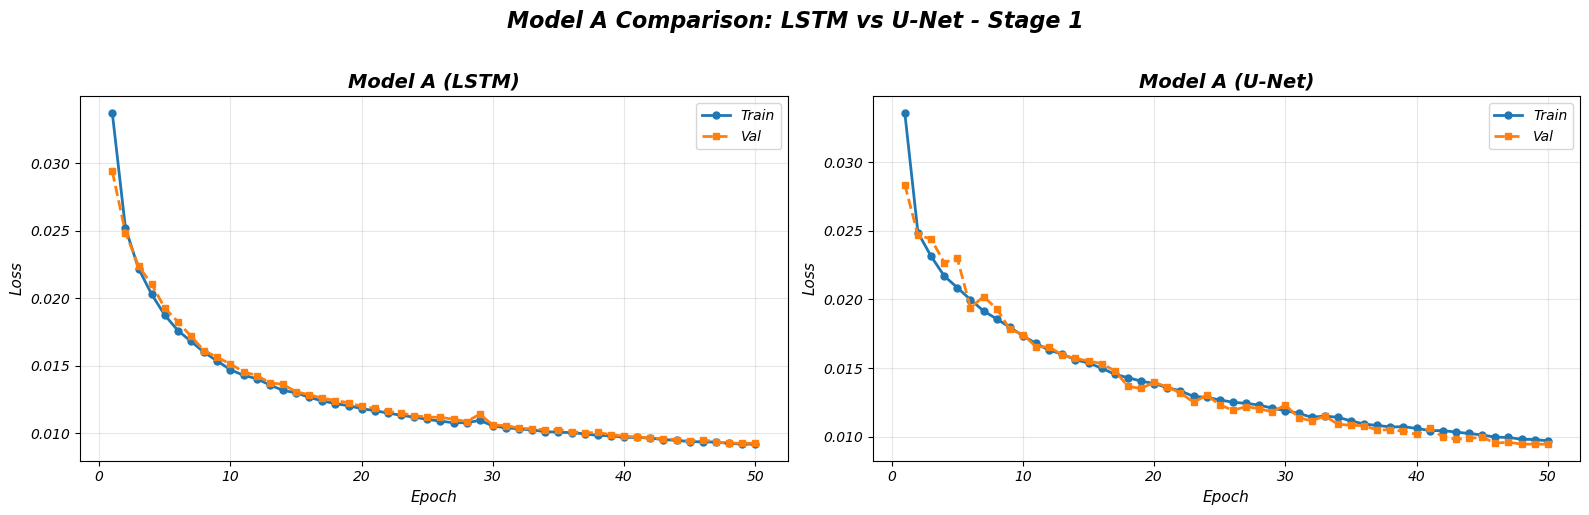


TRAINING SUMMARY

Model A (LSTM):
   Epochs: 50
   Best Val Loss: 0.009270 (epoch 50)
   Final Train Loss: 0.009203

Model A (U-Net):
   Epochs: 50
   Best Val Loss: 0.009448 (epoch 50)
   Final Train Loss: 0.009692

🏆 Best Performance: LSTM


In [ ]:
# ============================================================================
# PLOT TRAINING COMPARISON (STAGE 1)
# ============================================================================

# Load histories from checkpoints if not available
if not hist_lstm_s1:
    ckpt_lstm = CHECKPOINT_DIR / f"model_a_lstm_stage1_{CHUNK_DURATION:.0f}s.pth"
    hist_lstm_s1 = utils.load_training_history_from_checkpoint(ckpt_lstm)

if not hist_unet_s1:
    ckpt_unet = CHECKPOINT_DIR / f"model_a_unet_stage1_{CHUNK_DURATION:.0f}s.pth"
    hist_unet_s1 = utils.load_training_history_from_checkpoint(ckpt_unet)

# Plot comparison using utility function
utils.plot_model_comparison(hist_lstm_s1, hist_unet_s1,
                            title="Model A Comparison: LSTM vs U-Net - Stage 1")

## Stage 1 Evaluation (Spectrograms + Audio)

Compare LSTM vs U-Net separation quality on Stage 1 test samples.

In [ ]:
# ============================================================================
# STAGE 1 EVALUATION - INTERACTIVE INFERENCE ON TEST SONGS
# ============================================================================
print("="*70)
print("STAGE 1 EVALUATION: 2-Stem Mixture → Vocals")
print("="*70)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import torch

# Setup
model_lstm = model_lstm.to(device)
model_unet = model_unet.to(device)
model_lstm.eval()
model_unet.eval()

SR = 22050
DURATION = 120.0  # 2 minutes
CHUNK_LEN = 8.0   # 8 seconds

# Step 1: Locate test data directory
test_base = DATA_DIR / 'stage1' / 'test'
print(f"\n📂 Searching for test data at: {test_base}")

# Check for subdirectory structure or flat structure
if (test_base / 'mixture').exists():
    mix_dir = test_base / 'mixture'
    tgt_dir = test_base / 'target'
    print(f"✅ Found subdirectories: mixture/ and target/")
elif test_base.exists():
    mix_dir = test_dir = test_base
    print(f"✅ Using flat directory structure")
else:
    print(f"❌ ERROR: Test directory not found!")
    print(f"   Expected: {test_base}")
    print(f"   Please run preprocessing cells first.")
    raise FileNotFoundError(f"Test data directory not found: {test_base}")

# Step 2: Scan and organize chunks by song
all_mix_files = sorted(list(mix_dir.glob('*.npy')))
print(f"\n📊 Found {len(all_mix_files)} .npy files")

if len(all_mix_files) == 0:
    print("❌ No .npy files found! Check preprocessing.")
    raise FileNotFoundError("No test data files found")

# Parse filenames: Handle formats like "SongName_chunk0.npy" or "SongName_0.npy"
songs = {}
for f in all_mix_files:
    name = f.stem  # e.g., "Al James - Schoolboy Facination_chunk0"
    
    # Try to find chunk number at the end
    # Format 1: "SongName_chunk0" or "SongName_chunk123"
    # Format 2: "SongName_0" or "SongName_123"
    if '_chunk' in name:
        # Split by '_chunk' 
        parts = name.rsplit('_chunk', 1)
        if len(parts) == 2 and parts[1].isdigit():
            song_name = parts[0]
            idx = int(parts[1])
            if song_name not in songs:
                songs[song_name] = {}
            songs[song_name][idx] = f
    else:
        # Try standard format with underscore and number
        parts = name.split('_')
        if len(parts) >= 2 and parts[-1].isdigit():
            idx = int(parts[-1])
            # Remove 'mix' prefix if present
            name_parts = parts[1:-1] if parts[0].lower() == 'mix' else parts[:-1]
            song_name = '_'.join(name_parts)
            
            if song_name not in songs:
                songs[song_name] = {}
            songs[song_name][idx] = f

song_list = sorted(songs.keys())

if not song_list:
    print("❌ Could not parse song names from filenames")
    print(f"   Example file: {all_mix_files[0].name}")
    raise ValueError("Failed to parse song names")

print(f"\n🎵 Found {len(song_list)} songs:")
for i, name in enumerate(song_list[:10]):  # Show first 10
    chunk_count = len(songs[name])
    print(f"   [{i:2d}] {name} ({chunk_count} chunks)")
if len(song_list) > 10:
    print(f"   ... and {len(song_list) - 10} more")

# Step 3: User selection
print(f"\n📝 Select a song [0-{len(song_list)-1}] or press Enter for default (0):")
try:
    choice = input("Choice: ").strip()
    idx = int(choice) if choice else 0
    if not (0 <= idx < len(song_list)):
        idx = 0
        print(f"⚠️ Invalid choice, using default (0)")
except:
    idx = 0

selected = song_list[idx]
chunks = songs[selected]
print(f"✅ Selected: {selected}")

# Step 4: Load and stitch chunks with overlap-add
print(f"🧵 Loading and stitching chunks with 4s overlap...")

HOP_LENGTH = 4.0  # 4 second overlap
hop_samples = int(HOP_LENGTH * SR)
chunk_samples = int(CHUNK_LEN * SR)
num_needed = int(np.ceil(DURATION / HOP_LENGTH))

# Initialize output buffers
target_samples = int(DURATION * SR)
mix_wav = np.zeros(target_samples, dtype=np.float32)
tgt_wav = np.zeros(target_samples, dtype=np.float32)
mix_weights = np.zeros(target_samples, dtype=np.float32)
tgt_weights = np.zeros(target_samples, dtype=np.float32)

has_target = True
chunks_loaded = 0

# Overlap-add reconstruction
for i in range(num_needed):
    if i not in chunks:
        break
    
    # Calculate position (chunks overlap by 4s: chunk0 at 0s, chunk1 at 4s, etc.)
    pos = i * hop_samples
    
    # Load mix chunk
    mix_file = chunks[i]
    mix_chunk = np.load(mix_file)
    
    # Try to find corresponding target
    tgt_file = mix_file.name.replace('mix_', 'tgt_')
    tgt_path = (test_base / 'target' / tgt_file) if (test_base / 'target').exists() else (test_base / tgt_file)
    
    if tgt_path.exists():
        tgt_chunk = np.load(tgt_path)
    else:
        has_target = False
        tgt_chunk = np.zeros_like(mix_chunk)
        if i == 0:
            print(f"⚠️ No target file found (evaluation only)")
    
    # Determine valid length for this chunk
    valid_len = min(len(mix_chunk), target_samples - pos)
    if valid_len <= 0:
        break
    
    # Apply Hanning window for smooth overlap-add
    window = np.hanning(len(mix_chunk))[:valid_len]
    
    # Add to output with windowing
    mix_wav[pos:pos + valid_len] += mix_chunk[:valid_len] * window
    tgt_wav[pos:pos + valid_len] += tgt_chunk[:valid_len] * window
    mix_weights[pos:pos + valid_len] += window
    tgt_weights[pos:pos + valid_len] += window
    
    chunks_loaded += 1

if chunks_loaded == 0:
    raise ValueError("Failed to load any audio chunks")

# Normalize by overlap weights
mix_wav = np.divide(mix_wav, mix_weights, where=mix_weights > 0)
tgt_wav = np.divide(tgt_wav, tgt_weights, where=tgt_weights > 0)

print(f"✅ Stitched {chunks_loaded} overlapping chunks → {len(mix_wav)/SR:.1f}s audio")

# Step 5: Inference with sliding window
print("\n🚀 Running inference...")
print("LSTM:")
est_lstm = utils.sliding_window_inference(model_lstm, processor_lstm, mix_wav, 
                                         chunk_len=CHUNK_LEN, sr=SR, device=device)
print("U-Net:")
est_unet = utils.sliding_window_inference(model_unet, processor_unet, mix_wav,
                                         chunk_len=CHUNK_LEN, sr=SR, device=device)

# Step 6: Visualization
print(f"\n{'='*70}")
print("RESULTS")
print(f"{'='*70}\n")

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

axes[0,0].imshow(utils.to_spec(mix_wav, processor_lstm), aspect='auto', origin='lower', cmap='viridis')
axes[0,0].set_title("Input: 2-Stem Mixture", fontweight='bold')
axes[0,1].axis('off')
axes[0,1].text(0.5, 0.5, f"Song: {selected}\n\nDuration: {len(mix_wav)/SR:.1f}s\nStage: 1 (2→1)", 
               ha='center', va='center', fontsize=11, 
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

if has_target:
    axes[1,0].imshow(utils.to_spec(tgt_wav, processor_lstm), aspect='auto', origin='lower', cmap='viridis')
    axes[1,0].set_title("Ground Truth: Vocals", fontweight='bold')
else:
    axes[1,0].axis('off')
    axes[1,0].text(0.5, 0.5, "Target Not Available", ha='center', fontsize=12, color='gray')

axes[1,1].imshow(utils.to_spec(est_lstm, processor_lstm), aspect='auto', origin='lower', cmap='viridis')
axes[1,1].set_title("LSTM Prediction", fontweight='bold')

axes[2,0].imshow(utils.to_spec(est_unet, processor_unet), aspect='auto', origin='lower', cmap='viridis')
axes[2,0].set_title("U-Net Prediction", fontweight='bold')

#error map of unet
if has_target:
    axes[2,1].imshow(np.abs(utils.to_spec(est_unet, processor_unet) - utils.to_spec(tgt_wav, processor_lstm)), 
                     aspect='auto', origin='lower', cmap='magma')
else:
    axes[2,1].imshow(np.zeros_like(utils.to_spec(est_unet, processor_unet)), 
                     aspect='auto', origin='lower', cmap='magma')

plt.suptitle(f"Stage 1 Evaluation: {selected}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 7: Audio playback
print("🔊 Audio Samples:\n")
print("Input Mixture:")
display(Audio(mix_wav, rate=SR))

if has_target:
    print("\nGround Truth (Vocals):")
    display(Audio(tgt_wav, rate=SR))

print("\nLSTM Prediction:")
display(Audio(est_lstm, rate=SR))

print("\nU-Net Prediction:")
display(Audio(est_unet, rate=SR))

print(f"\n{'='*70}")
print("✅ EVALUATION COMPLETE")
print(f"{'='*70}")


STAGE 1 EVALUATION: 2-Stem Mixture → Vocals

📂 Searching for test data at: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\data\stage1\test
✅ Found subdirectories: mixture/ and target/

📊 Found 3041 .npy files

🎵 Found 50 songs:
   [ 0] AM Contra - Heart Peripheral (51 chunks)
   [ 1] Al James - Schoolboy Facination (49 chunks)
   [ 2] Angels In Amplifiers - I'm Alright (43 chunks)
   [ 3] Arise - Run Run Run (53 chunks)
   [ 4] BKS - Bulldozer (83 chunks)
   [ 5] BKS - Too Much (54 chunks)
   [ 6] Ben Carrigan - We'll Talk About It All Tonight (62 chunks)
   [ 7] Bobby Nobody - Stitch Up (54 chunks)
   [ 8] Buitraker - Revo X (67 chunks)
   [ 9] Carlos Gonzalez - A Place For Us (61 chunks)
   ... and 40 more

📝 Select a song [0-49] or press Enter for default (0):
✅ Selected: AM Contra - Heart Peripheral
🧵 Loading and stitching chunks with 4s overlap...
✅ Stitched 30 overlapping chunks → 120.0s audio

🚀 Running inference...
LSTM:
   P

KeyboardInterrupt: 

## Train Both Models - Stage 2

Curriculum step: Stage 2 uses 4→1 channels and continues from Stage 1 weights.

In [ ]:
# ============================================================================
# TRAIN BOTH MODEL A ARCHITECTURES - STAGE 2 (4 -> 1)
# ============================================================================
import torch.optim as optim
import torch.nn as nn
from models import model_A as ma  # <--- Essential import for manual init

STAGE2_ENABLED = True
SKIP_TRAINING_STAGE2 = False

# High-speed configurations
FAST_LSTM_CONFIG = utils.get_training_config_lstm()
FAST_LSTM_CONFIG['batch_size'] = 128

FAST_UNET_CONFIG = utils.get_training_config_unet()
FAST_UNET_CONFIG['batch_size'] = 32 # Safe batch size for A100 with massive spectrograms

# Checkpoints
ckpt_lstm_s2 = CHECKPOINT_DIR / f"model_a_lstm_stage2_{CHUNK_DURATION:.0f}s.pth"
ckpt_unet_s2 = CHECKPOINT_DIR / f"model_a_unet_stage2_{CHUNK_DURATION:.0f}s.pth"
ckpt_lstm_s1 = CHECKPOINT_DIR / f"model_a_lstm_stage1_{CHUNK_DURATION:.0f}s.pth"
ckpt_unet_s1 = CHECKPOINT_DIR / f"model_a_unet_stage1_{CHUNK_DURATION:.0f}s.pth"

hist_lstm_s2 = {}
hist_unet_s2 = {}

if not STAGE2_ENABLED:
    print("⏭️  Stage 2 training disabled (STAGE2_ENABLED = False)")
else:
    # --- LSTM ---
    print("1️⃣ Model A (LSTM) - Stage 2")
    print("-" * 70)

    # LSTM is standard, so utils.initialize is fine here
    model_lstm, processor_lstm, optimizer_lstm, loss_fn_lstm = utils.initialize_model_a_lstm(device)

    # Load Stage 1 weights
    if ckpt_lstm_s1.exists():
        print(f"📥 Loading Stage 1 weights from: {ckpt_lstm_s1.name}")
        checkpoint = torch.load(ckpt_lstm_s1, map_location=device)
        model_lstm.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ LSTM Stage 1 weights loaded successfully.")
    else:
        print("⚠️ LSTM Stage 1 checkpoint NOT found. Starting from scratch (not ideal).")

    hist_lstm_s2 = utils.train_model_stage(
        model=model_lstm,
        processor=processor_lstm,
        optimizer=optimizer_lstm,
        loss_fn=loss_fn_lstm,
        training_data_dir=DATA_DIR,
        stage="stage2",
        ckpt_path=ckpt_lstm_s2,
        device=device,
        train_config=FAST_LSTM_CONFIG, # Fast batch size
        skip_training=SKIP_TRAINING_STAGE2
    )

    # Free memory
    import gc
    model_lstm = model_lstm.to('cpu')
    del optimizer_lstm
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    # --- U-Net ---
    print("\n2️⃣ Model A (U-Net) - Stage 2")
    print("-" * 70)

    # 🛑 MANUAL INITIALIZATION (Must match Stage 1 structure exactly!)
    print("📉 Initializing Optimized U-Net for Stage 2 (32 filters, 5 layers)...")
    model_unet = ma.TimeFrequencyDomainUNet(
        in_channels=1,
        out_channels=1,
        base_filters=32,   # <--- MATCHES STAGE 1
        num_layers=5,      # <--- MATCHES STAGE 1
        batchnorm=True,
        dropout=0.1
    ).to(device)

    # Manual Optimizer Setup (since we skipped utils.init)
    processor_unet = utils.AudioProcessor(device=device)
    optimizer_unet = optim.Adam(model_unet.parameters(), lr=FAST_UNET_CONFIG['learning_rate'])
    loss_fn_unet = nn.MSELoss()

    # Load Stage 1 weights
    if ckpt_unet_s1.exists():
        print(f"📥 Loading Stage 1 weights from: {ckpt_unet_s1.name}")
        checkpoint = torch.load(ckpt_unet_s1, map_location=device)
        try:
            model_unet.load_state_dict(checkpoint['model_state_dict'])
            print(f"✅ U-Net Stage 1 weights loaded successfully.")
        except RuntimeError as e:
            print(f"❌ CRITICAL ERROR loading weights: {e}")
            print("   (This usually means the model structure in Stage 2 doesn't match Stage 1)")
            raise e
    else:
        print("⚠️ U-Net Stage 1 checkpoint NOT found. Starting from scratch.")

    hist_unet_s2 = utils.train_model_stage(
        model=model_unet,
        processor=processor_unet,
        optimizer=optimizer_unet,
        loss_fn=loss_fn_unet,
        training_data_dir=DATA_DIR,
        stage="stage2",
        ckpt_path=ckpt_unet_s2,
        device=device,
        train_config=FAST_UNET_CONFIG, # Fast batch size
        skip_training=SKIP_TRAINING_STAGE2
    )

print(f"\n{'='*70}")
print("✅ STAGE 2 COMPLETE!")
print(f"{'='*70}")

1️⃣ Model A (LSTM) - Stage 2
----------------------------------------------------------------------
📥 Loading Stage 1 weights from: model_a_lstm_stage1_8s.pth
✅ LSTM Stage 1 weights loaded successfully.
✅ Found checkpoint: model_a_lstm_stage2_8s.pth
   Best val loss: 0.010741


C:\Users\amita\AppData\Local\Temp\ipykernel_192516\4096106279.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_lstm_s1, map_location=device)


2️⃣ Model A (U-Net) - Stage 2
----------------------------------------------------------------------
📉 Initializing Optimized U-Net for Stage 2 (32 filters, 5 layers)...
📥 Loading Stage 1 weights from: model_a_unet_stage1_8s.pth
✅ U-Net Stage 1 weights loaded successfully.
✅ Found checkpoint: model_a_unet_stage2_8s.pth
   Best val loss: 0.009381

✅ STAGE 2 COMPLETE!


C:\Users\amita\AppData\Local\Temp\ipykernel_192516\4096106279.py:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_unet_s1, map_location=device)

## Stage 2 Test Evaluation

Compute loss on held-out test set (forward pass only) to assess generalization.


In [ ]:
# ============================================================================
# STAGE 2 TEST EVALUATION - FORWARD PASS ONLY (WITH CHECKPOINTING)
# ============================================================================

# Define checkpoint paths for test results (Stage 2)
test_results_ckpt_lstm_s2 = CHECKPOINT_DIR / f'test_results_lstm_stage2_{CHUNK_DURATION:.0f}s.pkl'
test_results_ckpt_unet_s2 = CHECKPOINT_DIR / f'test_results_unet_stage2_{CHUNK_DURATION:.0f}s.pkl'

# Try to load existing test results
test_lstm_s2 = utils.load_test_results(test_results_ckpt_lstm_s2)
test_unet_s2 = utils.load_test_results(test_results_ckpt_unet_s2)

if test_lstm_s2 and test_unet_s2:
    print(f"✅ Loaded cached test results from checkpoints")
    print(f"   LSTM: {test_results_ckpt_lstm_s2.name}")
    print(f"   U-Net: {test_results_ckpt_unet_s2.name}")
else:
    # Run evaluation if checkpoints don't exist
    print("📊 Running Stage 2 test evaluation (no cached results found)...")
    print()

    # Evaluate both models on test set
    print("\n" + "🧪 STAGE 2 TEST GENERALIZATION" + "\n")

    # --- Re-Initialize Models for Stage 2 ---
    # 1. LSTM
    model_lstm_s2, processor_lstm_s2, _, loss_fn_lstm_s2 = utils.initialize_model_a_lstm(device)
    
    # 2. U-Net (MANUAL INIT - LIGHT ARCHITECTURE)
    model_unet_s2 = ma.TimeFrequencyDomainUNet(
        in_channels=1,
        out_channels=1,
        base_filters=32,   # Match training config (Light)
        num_layers=5,      # Match training config
        batchnorm=True,
        dropout=0.1
    ).to(device)
    processor_unet_s2 = utils.AudioProcessor(device=device)
    loss_fn_unet_s2 = torch.nn.MSELoss()

    # Load LSTM Stage 2 weights
    if ckpt_lstm_s2.exists():
        print(f"📥 Loading LSTM Stage 2 weights from: {ckpt_lstm_s2.name}")
        checkpoint = torch.load(ckpt_lstm_s2, map_location=device, weights_only=False)
        model_lstm_s2.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ LSTM weights loaded (trained for {checkpoint.get('epoch', '?')} epochs)")
    else:
        print("⚠️ No LSTM Stage 2 checkpoint found - evaluating untrained model!")

    # Load U-Net Stage 2 weights 
    if ckpt_unet_s2.exists():
        print(f"📥 Loading U-Net Stage 2 weights from: {ckpt_unet_s2.name}")
        checkpoint = torch.load(ckpt_unet_s2, map_location=device, weights_only=False)
        model_unet_s2.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ U-Net weights loaded (trained for {checkpoint.get('epoch', '?')} epochs)")
    else:
        print("⚠️ No U-Net Stage 2 checkpoint found - evaluating untrained model!")

    print("\n" + "="*70)
    print("🔍 EVALUATING LSTM MODEL (STAGE 2)")
    print("="*70)
    test_lstm_s2 = utils.evaluate_test_set(model_lstm_s2, processor_lstm_s2, DATA_DIR,
                                          'stage2', loss_fn_lstm_s2, device)

    print("\n" + "="*70)
    print("🔍 EVALUATING U-NET MODEL (STAGE 2)")
    print("="*70)
    test_unet_s2 = utils.evaluate_test_set(model_unet_s2, processor_unet_s2, DATA_DIR,
                                          'stage2', loss_fn_unet_s2, device)
    
    # Save results to checkpoints
    utils.save_test_results(test_lstm_s2, test_results_ckpt_lstm_s2)
    utils.save_test_results(test_unet_s2, test_results_ckpt_unet_s2)

# Plot train/val/test comparison (using loaded or newly computed results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Check if history exists (it might be empty if we skipped training in this session)
if hist_lstm_s2:
    epochs_lstm = range(1, len(hist_lstm_s2['train_loss']) + 1)
    ax1.plot(epochs_lstm, hist_lstm_s2['train_loss'], 'o-', label='Train', linewidth=2)
    ax1.plot(epochs_lstm, hist_lstm_s2['val_loss'], 's--', label='Val', linewidth=2)
ax1.axhline(test_lstm_s2['mean'], color='red', linestyle=':', linewidth=2, label=f"Test (μ={test_lstm_s2['mean']:.4f})")
ax1.fill_between(range(1, 20),  # Dummy range if history missing
                 test_lstm_s2['mean'] - test_lstm_s2['std'],
                 test_lstm_s2['mean'] + test_lstm_s2['std'],
                 alpha=0.2, color='red')
ax1.set_title('Model A (LSTM) - Stage 2', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

if hist_unet_s2:
    epochs_unet = range(1, len(hist_unet_s2['train_loss']) + 1)
    ax2.plot(epochs_unet, hist_unet_s2['train_loss'], 'o-', label='Train', linewidth=2)
    ax2.plot(epochs_unet, hist_unet_s2['val_loss'], 's--', label='Val', linewidth=2)
ax2.axhline(test_unet_s2['mean'], color='red', linestyle=':', linewidth=2, label=f"Test (μ={test_unet_s2['mean']:.4f})")
ax2.fill_between(range(1, 20), 
                 test_unet_s2['mean'] - test_unet_s2['std'],
                 test_unet_s2['mean'] + test_unet_s2['std'],
                 alpha=0.2, color='red')
ax2.set_title('Model A (U-Net) - Stage 2', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Train/Val/Test Comparison - Stage 2 (Full Mix -> Vocals)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📊 Running Stage 2 test evaluation (no cached results found)...


🧪 STAGE 2 TEST GENERALIZATION

📥 Loading LSTM Stage 2 weights from: model_a_lstm_stage2_8s.pth
✅ LSTM weights loaded (trained for ? epochs)
📥 Loading U-Net Stage 2 weights from: model_a_unet_stage2_8s.pth
✅ U-Net weights loaded (trained for ? epochs)

🔍 EVALUATING LSTM MODEL (STAGE 2)
  Batch 1/96 | Loss: 0.038273


KeyboardInterrupt: 

## Compare Training Results (Stage 2)

Side-by-side comparison of U-Net vs LSTM training curves for Stage 2.

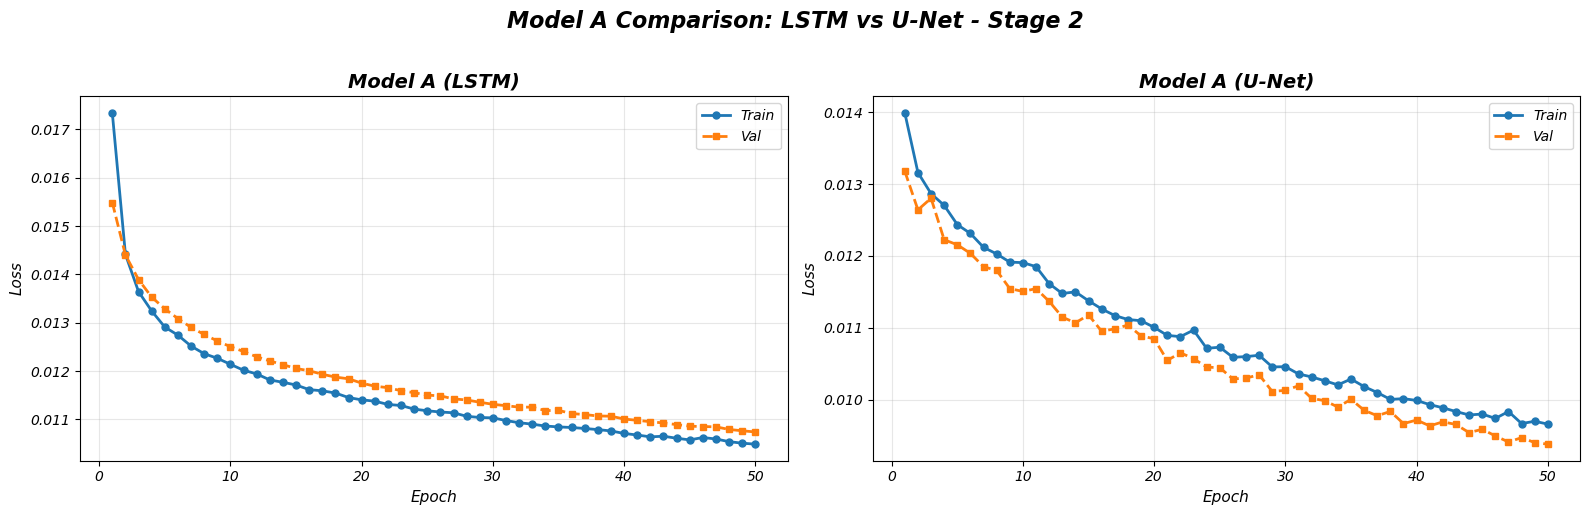


TRAINING SUMMARY

Model A (LSTM):
   Epochs: 50
   Best Val Loss: 0.010741 (epoch 50)
   Final Train Loss: 0.010489

Model A (U-Net):
   Epochs: 50
   Best Val Loss: 0.009381 (epoch 50)
   Final Train Loss: 0.009660

🏆 Best Performance: U-Net


In [ ]:
# ============================================================================
# PLOT TRAINING COMPARISON (STAGE 2)
# ============================================================================

if not STAGE2_ENABLED:
    print("⏭️  Stage 2 training disabled (STAGE2_ENABLED = False)")
else:
    if not hist_lstm_s2:
        ckpt_lstm_s2 = CHECKPOINT_DIR / f"model_a_lstm_stage2_{CHUNK_DURATION:.0f}s.pth"
        hist_lstm_s2 = utils.load_training_history_from_checkpoint(ckpt_lstm_s2)

    if not hist_unet_s2:
        ckpt_unet_s2 = CHECKPOINT_DIR / f"model_a_unet_stage2_{CHUNK_DURATION:.0f}s.pth"
        hist_unet_s2 = utils.load_training_history_from_checkpoint(ckpt_unet_s2)

    utils.plot_model_comparison(hist_lstm_s2, hist_unet_s2,
                                title="Model A Comparison: LSTM vs U-Net - Stage 2")

## Stage 2 Evaluation (Spectrograms + Audio)

Compare LSTM vs U-Net separation quality on Stage 2 test samples.

In [ ]:
# ============================================================================
# STAGE 2 EVALUATION - INTERACTIVE INFERENCE ON TEST SONGS
# ============================================================================
print("="*70)
print("STAGE 2 EVALUATION: Full Band Mixture → Vocals")
print("="*70)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import torch

# Setup
model_lstm = model_lstm.to(device)
model_unet = model_unet.to(device)
model_lstm.eval()
model_unet.eval()

SR = 22050
DURATION = 120.0  # 2 minutes
CHUNK_LEN = 8.0   # 8 seconds

# Step 1: Locate test data directory
test_base = DATA_DIR / 'stage2' / 'test'
print(f"\n📂 Searching for test data at: {test_base}")

# Check for subdirectory structure or flat structure
if (test_base / 'mixture').exists():
    mix_dir = test_base / 'mixture'
    tgt_dir = test_base / 'target'
    print(f"✅ Found subdirectories: mixture/ and target/")
elif test_base.exists():
    mix_dir = test_dir = test_base
    print(f"✅ Using flat directory structure")
else:
    print(f"❌ ERROR: Test directory not found!")
    print(f"   Expected: {test_base}")
    print(f"   Please run preprocessing cells first.")
    raise FileNotFoundError(f"Test data directory not found: {test_base}")

# Step 2: Scan and organize chunks by song
all_mix_files = sorted(list(mix_dir.glob('*.npy')))
print(f"\n📊 Found {len(all_mix_files)} .npy files")

if len(all_mix_files) == 0:
    print("❌ No .npy files found! Check preprocessing.")
    raise FileNotFoundError("No test data files found")

# Parse filenames: Handle formats like "SongName_chunk0.npy" or "SongName_0.npy"
songs = {}
for f in all_mix_files:
    name = f.stem
    
    if '_chunk' in name:
        parts = name.rsplit('_chunk', 1)
        if len(parts) == 2 and parts[1].isdigit():
            song_name = parts[0]
            idx = int(parts[1])
            if song_name not in songs:
                songs[song_name] = {}
            songs[song_name][idx] = f
    else:
        parts = name.split('_')
        if len(parts) >= 2 and parts[-1].isdigit():
            idx = int(parts[-1])
            name_parts = parts[1:-1] if parts[0].lower() == 'mix' else parts[:-1]
            song_name = '_'.join(name_parts)
            
            if song_name not in songs:
                songs[song_name] = {}
            songs[song_name][idx] = f

song_list = sorted(songs.keys())

if not song_list:
    print("❌ Could not parse song names from filenames")
    print(f"   Example file: {all_mix_files[0].name}")
    raise ValueError("Failed to parse song names")

print(f"\n🎵 Found {len(song_list)} songs:")
for i, name in enumerate(song_list[:10]):
    chunk_count = len(songs[name])
    print(f"   [{i:2d}] {name} ({chunk_count} chunks)")
if len(song_list) > 10:
    print(f"   ... and {len(song_list) - 10} more")

# Step 3: User selection
print(f"\n📝 Select a song [0-{len(song_list)-1}] or press Enter for default (0):")
try:
    choice = input("Choice: ").strip()
    idx = int(choice) if choice else 0
    if not (0 <= idx < len(song_list)):
        idx = 0
        print(f"⚠️ Invalid choice, using default (0)")
except:
    idx = 0

selected = song_list[idx]
chunks = songs[selected]
print(f"✅ Selected: {selected}")

# Step 4: Load and stitch chunks with overlap-add
print(f"🧵 Loading and stitching chunks with 4s overlap...")

HOP_LENGTH = 4.0
hop_samples = int(HOP_LENGTH * SR)
chunk_samples = int(CHUNK_LEN * SR)
num_needed = int(np.ceil(DURATION / HOP_LENGTH))

target_samples = int(DURATION * SR)
mix_wav = np.zeros(target_samples, dtype=np.float32)
tgt_wav = np.zeros(target_samples, dtype=np.float32)
mix_weights = np.zeros(target_samples, dtype=np.float32)
tgt_weights = np.zeros(target_samples, dtype=np.float32)

has_target = True
chunks_loaded = 0

for i in range(num_needed):
    if i not in chunks:
        break
    
    pos = i * hop_samples
    mix_file = chunks[i]
    mix_chunk = np.load(mix_file)
    
    tgt_file = mix_file.name.replace('mix_', 'tgt_')
    tgt_path = (test_base / 'target' / tgt_file) if (test_base / 'target').exists() else (test_base / tgt_file)
    
    if tgt_path.exists():
        tgt_chunk = np.load(tgt_path)
    else:
        has_target = False
        tgt_chunk = np.zeros_like(mix_chunk)
        if i == 0:
            print(f"⚠️ No target file found (evaluation only)")
    
    valid_len = min(len(mix_chunk), target_samples - pos)
    if valid_len <= 0:
        break
    
    window = np.hanning(len(mix_chunk))[:valid_len]
    
    mix_wav[pos:pos + valid_len] += mix_chunk[:valid_len] * window
    tgt_wav[pos:pos + valid_len] += tgt_chunk[:valid_len] * window
    mix_weights[pos:pos + valid_len] += window
    tgt_weights[pos:pos + valid_len] += window
    
    chunks_loaded += 1

if chunks_loaded == 0:
    raise ValueError("Failed to load any audio chunks")

mix_wav = np.divide(mix_wav, mix_weights, where=mix_weights > 0)
tgt_wav = np.divide(tgt_wav, tgt_weights, where=tgt_weights > 0)

print(f"✅ Stitched {chunks_loaded} overlapping chunks → {len(mix_wav)/SR:.1f}s audio")

# Step 5: Inference with sliding window (using utility function)
print("\n🚀 Running inference...")
print("LSTM (Stage 2):")
est_lstm_s2 = utils.sliding_window_inference(model_lstm, processor_lstm, mix_wav, 
                                            chunk_len=CHUNK_LEN, sr=SR, device=device)
print("U-Net (Stage 2):")
est_unet_s2 = utils.sliding_window_inference(model_unet, processor_unet, mix_wav,
                                            chunk_len=CHUNK_LEN, sr=SR, device=device)

# Step 6: Visualization
print(f"\n{'='*70}")
print("RESULTS")
print(f"{'='*70}\n")

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

axes[0,0].imshow(utils.to_spec(mix_wav, processor_lstm), aspect='auto', origin='lower', cmap='viridis')
axes[0,0].set_title("Input: Full Band Mixture", fontweight='bold')
axes[0,1].axis('off')
axes[0,1].text(0.5, 0.5, f"Song: {selected}\n\nDuration: {len(mix_wav)/SR:.1f}s\nStage: 2 (Full Band → Vocals)", 
               ha='center', va='center', fontsize=11, 
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

if has_target:
    axes[1,0].imshow(utils.to_spec(tgt_wav, processor_lstm), aspect='auto', origin='lower', cmap='viridis')
    axes[1,0].set_title("Ground Truth: Vocals", fontweight='bold')
else:
    axes[1,0].axis('off')
    axes[1,0].text(0.5, 0.5, "Target Not Available", ha='center', fontsize=12, color='gray')

axes[1,1].imshow(utils.to_spec(est_lstm_s2, processor_lstm), aspect='auto', origin='lower', cmap='viridis')
axes[1,1].set_title("LSTM-S2 Prediction", fontweight='bold')

axes[2,0].imshow(utils.to_spec(est_unet_s2, processor_unet), aspect='auto', origin='lower', cmap='viridis')
axes[2,0].set_title("U-Net-S2 Prediction", fontweight='bold')
axes[2,1].axis('off')

plt.suptitle(f"Stage 2 Evaluation: {selected}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 7: Audio playback
print("🔊 Audio Samples:\n")
print("Input Full Band Mix:")
display(Audio(mix_wav, rate=SR))

if has_target:
    print("\nGround Truth (Vocals):")
    display(Audio(tgt_wav, rate=SR))

print("\nLSTM-S2 Prediction:")
display(Audio(est_lstm_s2, rate=SR))

print("\nU-Net-S2 Prediction:")
display(Audio(est_unet_s2, rate=SR))

print(f"\n{'='*70}")
print("✅ EVALUATION COMPLETE")
print(f"{'='*70}")


STAGE 2 EVALUATION: Full Band Mixture → Vocals

📂 Searching for test data at: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\data\stage2\test
✅ Found subdirectories: mixture/ and target/

📊 Found 3041 .npy files

🎵 Found 50 songs:
   [ 0] AM Contra - Heart Peripheral (51 chunks)
   [ 1] Al James - Schoolboy Facination (49 chunks)
   [ 2] Angels In Amplifiers - I'm Alright (43 chunks)
   [ 3] Arise - Run Run Run (53 chunks)
   [ 4] BKS - Bulldozer (83 chunks)
   [ 5] BKS - Too Much (54 chunks)
   [ 6] Ben Carrigan - We'll Talk About It All Tonight (62 chunks)
   [ 7] Bobby Nobody - Stitch Up (54 chunks)
   [ 8] Buitraker - Revo X (67 chunks)
   [ 9] Carlos Gonzalez - A Place For Us (61 chunks)
   ... and 40 more

📝 Select a song [0-49] or press Enter for default (0):
✅ Selected: AM Contra - Heart Peripheral
🧵 Loading and stitching chunks with 4s overlap...
✅ Stitched 30 overlapping chunks → 120.0s audio

🚀 Running inference...
LSTM (S

KeyboardInterrupt: 

## Quantitative Evaluation

Compute BSS metrics (SDR/SIR/SAR) on test set using museval library.

QUANTITATIVE EVALUATION - SDR/SIR/SAR METRICS (stage2)

Evaluating on 10 test samples...

  Sample 1/10 - LSTM: SDR=3.73 | U-Net: SDR=6.34
  Sample 2/10 - LSTM: SDR=6.66 | U-Net: SDR=9.85
  Sample 3/10 - LSTM: SDR=9.16 | U-Net: SDR=9.75
  Sample 4/10 - LSTM: SDR=7.58 | U-Net: SDR=7.61
  Sample 5/10 - LSTM: SDR=6.43 | U-Net: SDR=6.97
  Sample 6/10 - LSTM: SDR=6.47 | U-Net: SDR=7.08
  Sample 7/10 - LSTM: SDR=3.63 | U-Net: SDR=3.71
  Sample 8/10 - LSTM: SDR=3.81 | U-Net: SDR=3.73
  Sample 9/10 - LSTM: SDR=9.21 | U-Net: SDR=8.54


c:\Users\amita\anaconda3\envs\final-dl-env\lib\site-packages\numpy\_core\_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\amita\anaconda3\envs\final-dl-env\lib\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


  Sample 10/10 - LSTM: SDR=9.17 | U-Net: SDR=10.25

EVALUATION RESULTS

Model A (LSTM):
   SDR: 6.58 ± 2.14 dB
   SIR: 14.83 ± 1.69 dB
   SAR: inf ± nan dB

Model A (U-Net):
   SDR: 7.38 ± 2.22 dB
   SIR: 16.36 ± 1.58 dB
   SAR: inf ± nan dB

📊 Reference (Paper): SI-SDRi ~6.93 dB for vocals

🏆 Best SDR: U-Net (+0.80 dB)


posx and posy should be finite values


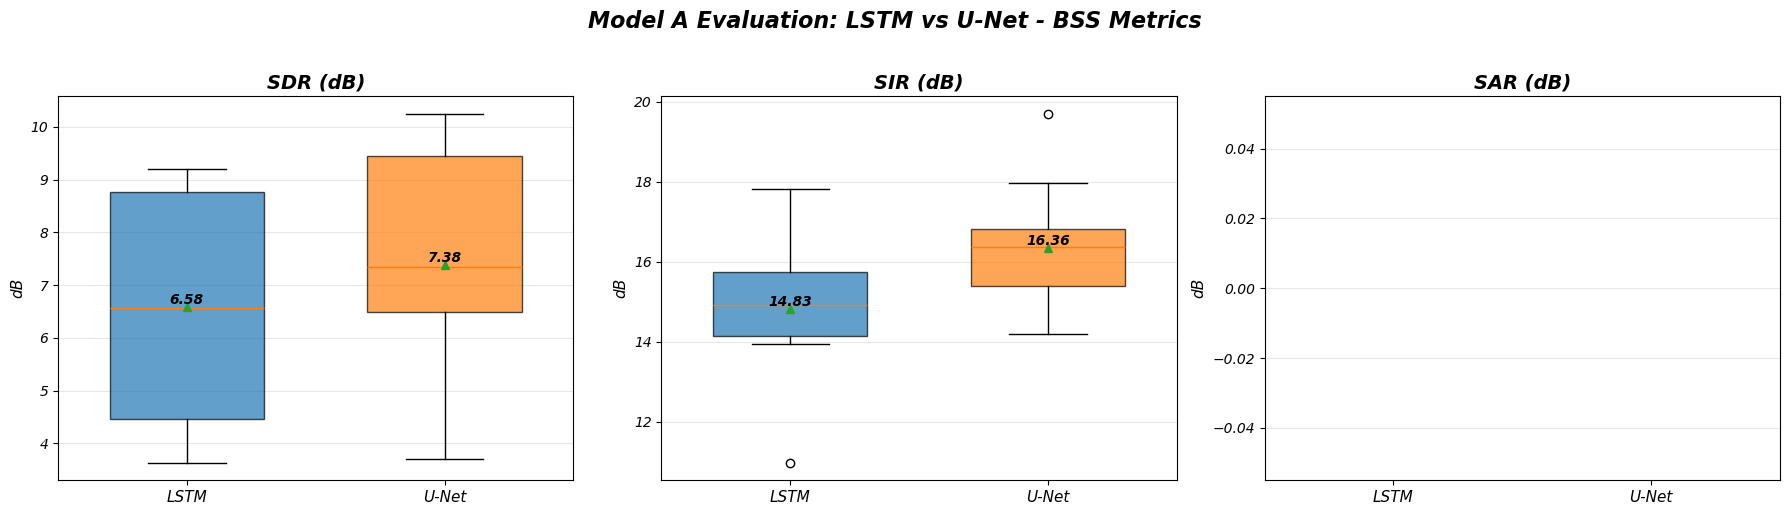

In [ ]:
# ============================================================================
# QUANTITATIVE EVALUATION - BSS METRICS
# ============================================================================

# Reload utils to get latest fixes
import importlib
importlib.reload(utils)

NUM_TEST_SAMPLES = 10
STAGE_FOR_EVAL = "stage2" if STAGE2_ENABLED else "stage1"

# Evaluate both models using utility function
metrics = utils.evaluate_separation_quality(
    model_lstm=model_lstm,
    model_unet=model_unet,
    processor_lstm=processor_lstm,
    processor_unet=processor_unet,
    test_data_dir=DATA_DIR,
    stage=STAGE_FOR_EVAL,
    num_samples=NUM_TEST_SAMPLES,
    sr=22050,
    device=device
)

## Optional: Custom Song Inference (Upload)

Upload a song (or place it in the folder below) and run inference with both models. This is the final step.

In [ ]:
# ============================================================================
# CUSTOM SONG INFERENCE (UPLOAD OR LOCAL FOLDER)
# ============================================================================

UPLOAD_DIR = DATA_DIR / "user_uploads"
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

# Colab upload
if IN_COLAB:
    try:
        from google.colab import files
        uploaded = files.upload()
        for name, data in uploaded.items():
            out_path = UPLOAD_DIR / name
            with open(out_path, "wb") as f:
                f.write(data)
            print(f"✅ Saved: {out_path}")
    except Exception as e:
        print(f"⚠️  Colab upload failed: {e}")
        print(f"Place a file manually in: {UPLOAD_DIR}")
else:
    print(f"📁 Place your audio file in: {UPLOAD_DIR}")

# Pick the most recent audio file
exts = ["*.wav", "*.mp3", "*.flac", "*.ogg", "*.m4a"]
audio_files = []
for ext in exts:
    audio_files += list(UPLOAD_DIR.glob(ext))

audio_files = sorted(audio_files, key=lambda p: p.stat().st_mtime, reverse=True)

if not audio_files:
    print("⚠️  No audio files found in upload folder.")
else:
    audio_path = audio_files[0]
    print(f"🎵 Using file: {audio_path.name}")

    utils.compare_models_on_audio_file(
        file_path=audio_path,
        model_lstm=model_lstm,
        model_unet=model_unet,
        processor_lstm=processor_lstm,
        processor_unet=processor_unet,
        device=device,
        sr=22050,
        duration=15  # seconds (set None for full length)
    )

📁 Place your audio file in: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\data\user_uploads
🎵 Using file: Dire Straits - Tunnel Of Love.mp3


AttributeError: module 'models.utils' has no attribute 'compare_models_on_audio_file'